# Differential Evolution 差分进化

## 本 Notebook 的教学目标

1. 理解该算法的搜索直觉。
2. 使用一个经典二维优化问题完成从零实现。
3. 通过可视化观察算法如何移动、如何收敛、可能会遇到什么问题。
4. 通过多次运行和参数实验建立更稳固的算法直觉。

## 实验问题

本实验使用 **Ackley 函数**。该函数表面多峰且复杂，很适合展示差分变异带来的全局探索能力。

在教学上，二维问题有一个明显优势：**我们可以直接把搜索轨迹画出来**。这比只看一串数值更适合课堂演示。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 统一图表风格，保证讲课时图表更清晰。
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# 本项目统一使用二维测试函数，这样可以把搜索轨迹直接画在等高线上。

def make_grid(bounds, step=250):
    xs = np.linspace(bounds[0, 0], bounds[0, 1], step)
    ys = np.linspace(bounds[1, 0], bounds[1, 1], step)
    xx, yy = np.meshgrid(xs, ys)
    return xs, ys, xx, yy


def evaluate_on_grid(objective, bounds, step=250):
    xs, ys, xx, yy = make_grid(bounds, step=step)
    zz = np.vectorize(lambda a, b: objective(np.array([a, b])))(xx, yy)
    return xs, ys, xx, yy, zz


def plot_contour_with_trace(objective, bounds, trace, title, levels=40):
    xs, ys, xx, yy, zz = evaluate_on_grid(objective, bounds)
    plt.figure(figsize=(9, 7))
    contour = plt.contourf(xx, yy, zz, levels=levels, cmap='viridis')
    plt.colorbar(contour, label='Objective value')

    trace = np.array(trace)
    plt.plot(trace[:, 0], trace[:, 1], color='white', lw=2, alpha=0.9, label='Search trace')
    plt.scatter(trace[:, 0], trace[:, 1], c=np.arange(len(trace)), cmap='coolwarm', s=40, edgecolor='black')
    plt.scatter(trace[0, 0], trace[0, 1], color='gold', s=120, marker='o', edgecolor='black', label='Start')
    plt.scatter(trace[-1, 0], trace[-1, 1], color='red', s=160, marker='*', edgecolor='black', label='End / Best')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()


def summarize_runs(scores):
    return pd.Series({
        'best': float(np.min(scores)),
        'mean': float(np.mean(scores)),
        'worst': float(np.max(scores)),
        'std': float(np.std(scores)),
    })


# Ackley 函数常用于测试群体优化算法的全局搜索能力。
def objective(point):
    x, y = point
    term_1 = -20 * np.exp(-0.2 * np.sqrt(0.5 * (x ** 2 + y ** 2)))
    term_2 = -np.exp(0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)))
    return term_1 + term_2 + np.e + 20

bounds = np.array([[-5, 5], [-5, 5]], dtype=float)

## 算法直觉

核心思想：用多个个体之间的“差值向量”来构造新候选解，从而形成一种既利用当前信息、又能保持探索能力的变异方式。

为了让课堂节奏更清楚，Notebook 里的实现会优先追求**可读性**，而不是极端性能优化。

In [2]:
def differential_evolution(objective, bounds, population_size=24, n_generations=70, F=0.7, CR=0.9, seed=0):
    rng = np.random.default_rng(seed)
    dim = len(bounds)

    population = rng.uniform(bounds[:, 0], bounds[:, 1], size=(population_size, dim))
    scores = np.apply_along_axis(objective, 1, population)

    history = [population.copy()]
    best_scores = [float(scores.min())]

    for _ in range(n_generations):
        for i in range(population_size):
            # 差分进化的核心：随机选出三个不同个体，用它们的差值生成变异向量。
            indices = [idx for idx in range(population_size) if idx != i]
            a, b, c = population[rng.choice(indices, size=3, replace=False)]
            mutant = np.clip(a + F * (b - c), bounds[:, 0], bounds[:, 1])

            # 二项式交叉：将当前个体和变异个体混合，形成试验个体。
            cross_points = rng.random(dim) < CR
            if not np.any(cross_points):
                cross_points[rng.integers(0, dim)] = True
            trial = np.where(cross_points, mutant, population[i])
            trial_score = objective(trial)

            # 贪心选择：试验个体更优时，用它替换当前个体。
            if trial_score < scores[i]:
                population[i] = trial
                scores[i] = trial_score

        history.append(population.copy())
        best_scores.append(float(scores.min()))

    best_idx = int(np.argmin(scores))
    return {
        'best': population[best_idx],
        'best_score': float(scores[best_idx]),
        'history': history,
        'best_scores': np.array(best_scores),
    }

## 单次实验演示

下面先运行一次实验，重点观察两件事：

1. 搜索轨迹是否平滑、是否容易停在局部区域。
2. 目标值是否快速下降，以及下降到什么程度后开始停滞。

best point: [-0. -0.]
best score: 0.0


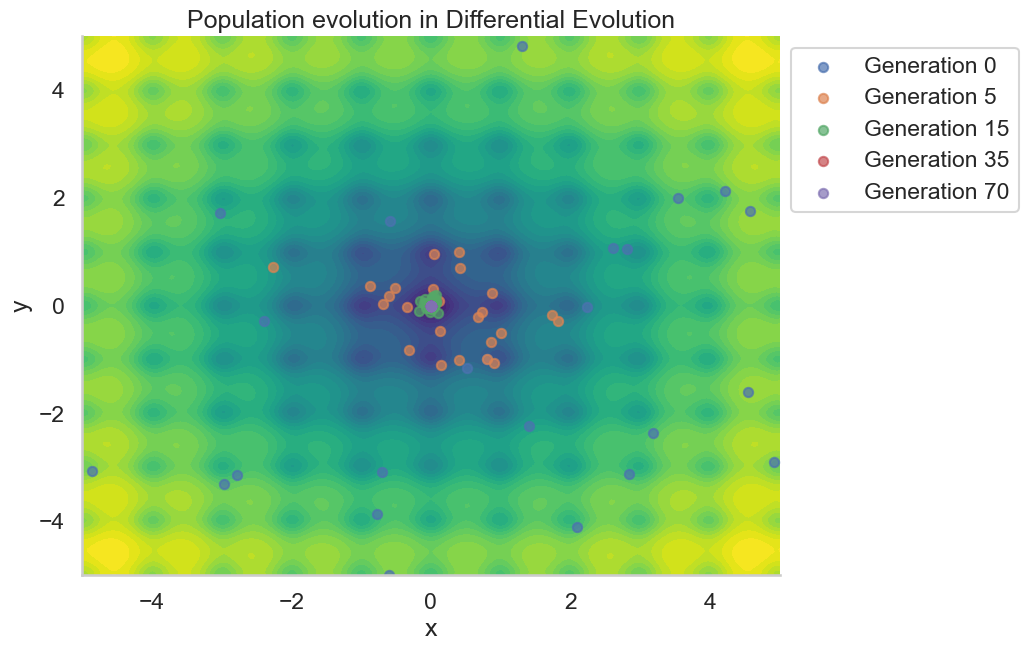

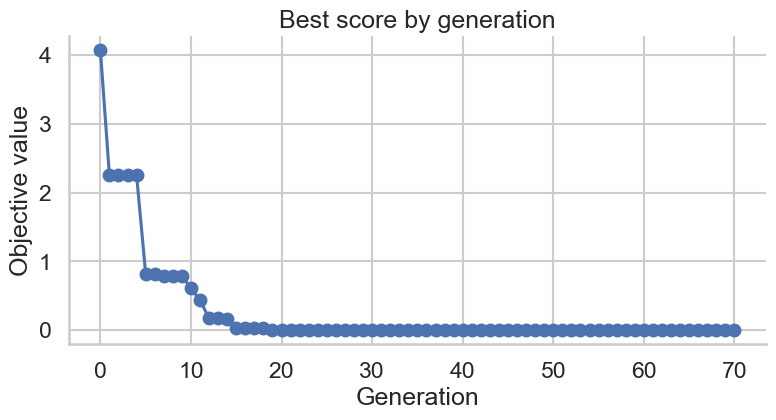

In [3]:
de_result = differential_evolution(objective, bounds, seed=21)
print('best point:', np.round(de_result['best'], 4))
print('best score:', round(de_result['best_score'], 6))

xs, ys, xx, yy, zz = evaluate_on_grid(objective, bounds)
plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, zz, levels=40, cmap='viridis')
for idx in [0, 5, 15, 35, 70]:
    population = de_result['history'][idx]
    plt.scatter(population[:, 0], population[:, 1], s=45, alpha=0.7, label=f'Generation {idx}')
plt.title('Population evolution in Differential Evolution')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(de_result['best_scores'], marker='o')
plt.title('Best score by generation')
plt.xlabel('Generation')
plt.ylabel('Objective value')
plt.show()

## 多次运行与参数分析

单次实验只能告诉我们“这一次发生了什么”，但讲课时更重要的是说明：

1. 算法是否稳定。
2. 算法是否依赖初始条件。
3. 关键参数变化后，会如何影响最终表现。

,Differential Evolution statistics
best,2.283873e-08
mean,1.368603e-07
worst,3.110327e-07
std,8.767996e-08


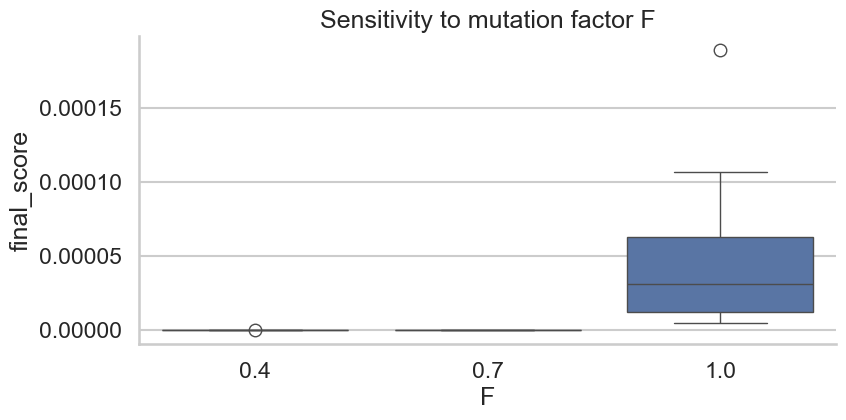

In [4]:
run_scores = [differential_evolution(objective, bounds, seed=seed)['best_score'] for seed in range(20)]
display(summarize_runs(run_scores).to_frame(name='Differential Evolution statistics'))

# 参数敏感性：F 控制差分步长，过小会保守，过大则会震荡。
F_values = [0.4, 0.7, 1.0]
records = []
for F in F_values:
    for seed in range(10):
        score = differential_evolution(objective, bounds, F=F, seed=seed)['best_score']
        records.append({'F': F, 'final_score': score})

param_df = pd.DataFrame(records)
plt.figure(figsize=(9, 4))
sns.boxplot(data=param_df, x='F', y='final_score')
plt.title('Sensitivity to mutation factor F')
plt.show()

## 课堂总结

讲解这一类算法时，建议把重点放在以下问题上：

1. 算法的探索能力来自哪里。
2. 算法的利用能力来自哪里。
3. 它最容易失败的场景是什么。
4. 参数变化时，算法行为为什么会改变。

把这四个问题讲清楚，学生通常就能真正建立算法直觉。